<a href="https://colab.research.google.com/github/Moe-phantom/Safety-Constrained-TTC-for-Self-Improving-Industrial-Anomaly-Attribution/blob/main/notebook2_cross_severity_v5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2 (v5): Dual-Track SVM Baseline — Experiment 1
**IEEE IES GenAI Challenge 2026**

## Changes in v5 (fixes over v4)

1. **Envelope spectrum features** — implements Smith & Randall (2015) methodology:
   spectral kurtosis band selection → bandpass → Hilbert → squared envelope spectrum.
   Band energies now extracted from the *envelope* spectrum, not the raw FFT.

2. **Band definitions corrected:**
   - `BSF_band` now targets 1×BSF (≈70.6 Hz), not 2×BSF (≈141 Hz)
   - `BPFI_band` / `BSF_band` overlap eliminated (was 9 Hz shared at 147–156 Hz)
   - Added `BPFI_sideband` (fr sidebands) and `BSF_ftf_sideband` (FTF sidebands)

3. **Normal class leakage fixed** — Track B Normal test samples use time-based
   split (last 30% of 97.mat), not random sampling from the same pool as training.

4. **Severity fallback is now explicit** — if 0.021 files are missing, the notebook
   raises an error instead of silently falling back to 0.014.

## Two experimental tracks

**Track A — Matched condition (Experiment 1a):**
Train and test on 0HP, 0.007 inch fault diameter. SVM achieves ~100%.

**Track B — Cross-severity generalization (Experiment 1b):**
Train on 0HP, 0.007 inch. Test on 0HP, 0.021 inch.
Feature distributions shift dramatically with severity. SVM degrades →
creates real misclassifications for TTC recovery in Notebook 3.

**CWRU files needed for Track B (0HP):**

| Fault      | 0.021 inch |
|------------|------------|
| Inner Race | 209.mat    |
| Ball       | 222.mat    |
| Outer Race | 234.mat    |
| Normal     | 97.mat (time-split: last 30%) |

Download from: https://engineering.case.edu/bearingdatacenter/download-data-file
Upload to `cwru_data/` in Colab.

In [1]:
!pip install scikit-learn matplotlib seaborn scipy -q

In [2]:
"""
Data Processing and Machine Learning Imports
IEEE IES GenAI Challenge 2026 - Notebook 2 (v5)
"""

# --- Standard Library ---
import pickle
import urllib.request
from pathlib import Path

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- SciPy Modules ---
from scipy.io import loadmat
from scipy.fft import fft, fftfreq
from scipy.signal import hilbert, butter, filtfilt
from scipy.stats import kurtosis, skew

# --- Scikit-Learn Modules ---
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

if __name__ == "__main__":
    print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


## Bearing Geometry & Corrected Fault Frequency Bands

SKF 6205-2RS JEM (Drive End) at 1797 RPM. All frequencies computed from
manufacturer geometry — not rounded or approximate.

**Band corrections over v4:**
- `BSF_band`: now (63, 79) Hz targeting 1×BSF=70.6 Hz. v4 used (126, 156) which
  captured 2×BSF=141.2 Hz and overlapped with BPFI_band.
- `BPFI_band`: now (155, 170) Hz, tightened to avoid overlap.
- Added envelope-domain sideband features per Smith & Randall.

In [3]:
# ── SKF 6205-2RS JEM bearing geometry (Drive End) ──────────────────────────
RPM = 1797
FR  = RPM / 60.0          # shaft frequency = 29.95 Hz
N_BALLS = 9
BD = 7.938                 # ball diameter (mm)
PD = 39.04                 # pitch diameter (mm)

# Theoretical characteristic frequencies
BPFO = (N_BALLS / 2) * FR * (1 - BD / PD)              # 107.37 Hz
BPFI = (N_BALLS / 2) * FR * (1 + BD / PD)              # 162.18 Hz
BSF  = (PD / (2 * BD)) * FR * (1 - (BD / PD)**2)       # 70.60 Hz
FTF  = 0.5 * FR * (1 - BD / PD)                        # 11.93 Hz (cage)

print(f'Shaft freq (fr)  : {FR:.2f} Hz')
print(f'BPFO             : {BPFO:.2f} Hz')
print(f'BPFI             : {BPFI:.2f} Hz')
print(f'BSF  (1×)        : {BSF:.2f} Hz')
print(f'BSF  (2×)        : {2*BSF:.2f} Hz')
print(f'FTF  (cage)      : {FTF:.2f} Hz')
print(f'BPFI - fr        : {BPFI-FR:.2f} Hz  (inner race lower sideband)')
print(f'BPFI + fr        : {BPFI+FR:.2f} Hz  (inner race upper sideband)')
print(f'BSF  - FTF       : {BSF-FTF:.2f} Hz  (ball cage lower sideband)')
print(f'BSF  + FTF       : {BSF+FTF:.2f} Hz  (ball cage upper sideband)')

# ── Feature extraction config ──────────────────────────────────────────────
WINDOW_SIZE = 1024
STRIDE      = 512
FS          = 12000

BW      = 8  # Hz half-width for BPFO, BPFI, and their sidebands
BW_bsf  = 5  # Hz half-width for BSF and its FTF sidebands (FTF=11.93 Hz, ±8 would overlap)

FAULT_BANDS = {
    'BPFO_band':          (BPFO - BW, BPFO + BW),
    'BPFI_band':          (BPFI - BW, BPFI + BW),
    'BSF_band':           (BSF  - BW_bsf, BSF  + BW_bsf),          # ±5 Hz
    'BPFI_sb_lo':         (BPFI - FR - BW, BPFI - FR + BW),
    'BPFI_sb_hi':         (BPFI + FR - BW, BPFI + FR + BW),
    'BSF_ftf_sb_lo':      (BSF - FTF - BW_bsf, BSF - FTF + BW_bsf),  # ±5 Hz
    'BSF_ftf_sb_hi':      (BSF + FTF - BW_bsf, BSF + FTF + BW_bsf),  # ±5 Hz
    'FTF_band':           (FTF - 4, FTF + 4),
}

# Verify no overlaps
band_names = list(FAULT_BANDS.keys())
for i in range(len(band_names)):
    for j in range(i+1, len(band_names)):
        lo1, hi1 = FAULT_BANDS[band_names[i]]
        lo2, hi2 = FAULT_BANDS[band_names[j]]
        ov = max(0, min(hi1, hi2) - max(lo1, lo2))
        if ov > 0:
            print(f'⚠️ OVERLAP: {band_names[i]} ∩ {band_names[j]} = {ov:.1f} Hz')
print('✅ Band definitions verified — no overlaps.')

print('\nBand summary:')
for name, (lo, hi) in FAULT_BANDS.items():
    print(f'  {name:20s}: ({lo:6.1f}, {hi:6.1f}) Hz  [center={((lo+hi)/2):.1f}]')

LABEL_MAP   = {0: 'Normal', 1: 'Inner Race', 2: 'Outer Race', 3: 'Ball'}
NAME_TO_ID  = {v: k for k, v in LABEL_MAP.items()}

# Feature columns — envelope spectrum band energies + time/spectral stats
FEATURE_COLS = [
    'rms', 'peak', 'crest_factor', 'kurtosis', 'skewness',
    'variance', 'shape_factor', 'impulse_factor',
    'dom_freq_hz', 'dom_magnitude', 'spec_centroid', 'spec_spread',
    'BPFI_band', 'BPFO_band', 'BSF_band',
    'BPFI_sb_lo', 'BPFI_sb_hi',
    'BSF_ftf_sb_lo', 'BSF_ftf_sb_hi',
    'FTF_band',
]

Shaft freq (fr)  : 29.95 Hz
BPFO             : 107.37 Hz
BPFI             : 162.18 Hz
BSF  (1×)        : 70.60 Hz
BSF  (2×)        : 141.21 Hz
FTF  (cage)      : 11.93 Hz
BPFI - fr        : 132.23 Hz  (inner race lower sideband)
BPFI + fr        : 192.13 Hz  (inner race upper sideband)
BSF  - FTF       : 58.67 Hz  (ball cage lower sideband)
BSF  + FTF       : 82.53 Hz  (ball cage upper sideband)
✅ Band definitions verified — no overlaps.

Band summary:
  BPFO_band           : (  99.4,  115.4) Hz  [center=107.4]
  BPFI_band           : ( 154.2,  170.2) Hz  [center=162.2]
  BSF_band            : (  65.6,   75.6) Hz  [center=70.6]
  BPFI_sb_lo          : ( 124.2,  140.2) Hz  [center=132.2]
  BPFI_sb_hi          : ( 184.1,  200.1) Hz  [center=192.1]
  BSF_ftf_sb_lo       : (  53.7,   63.7) Hz  [center=58.7]
  BSF_ftf_sb_hi       : (  77.5,   87.5) Hz  [center=82.5]
  FTF_band            : (   7.9,   15.9) Hz  [center=11.9]


## Feature Extraction — Envelope Spectrum (Smith & Randall 2015)

**Pipeline per segment:**
1. Spectral kurtosis (single-resolution fast approximation) → find resonance band
2. Bandpass filter around resonance → Hilbert transform → squared envelope
3. FFT of squared envelope → extract energy in narrow bands around fault frequencies

This replaces the raw-FFT band energy approach in v4.

In [4]:
def extract_de_signal(mat_path):
    mat = loadmat(mat_path)
    de_keys = [k for k in mat.keys() if 'DE_time' in k]
    if not de_keys:
        raise ValueError(f'No DE_time in {mat_path}. Keys: {list(mat.keys())}')
    return mat[de_keys[0]].flatten()

def segment_signal(signal, window_size=WINDOW_SIZE, stride=STRIDE):
    segments = []
    start = 0
    while start + window_size <= len(signal):
        segments.append(signal[start:start + window_size])
        start += stride
    return np.array(segments)


def find_resonance_band(signal, fs, window_size=256):
    """
    Fast spectral kurtosis — single-resolution STFT approximation.
    Returns (center_freq, bandwidth) of the most impulsive band.
    Note: this is NOT the full Antoni kurtogram (which searches a 2-D
    frequency×bandwidth tree). It's a practical approximation that works
    for CWRU data where resonances are strong and well-separated.
    """
    n_windows = len(signal) // window_size
    if n_windows < 4:
        # Fallback: use broadband 1–5 kHz
        return 3000, 2000
    signal_trimmed = signal[:n_windows * window_size]
    frames = signal_trimmed.reshape(n_windows, window_size)
    spectra = np.abs(np.fft.rfft(frames, axis=1)) ** 2
    freqs = np.fft.rfftfreq(window_size, 1/fs)
    # Spectral kurtosis at each frequency bin
    mean_psd = spectra.mean(axis=0)
    mean_psd4 = (spectra ** 2).mean(axis=0)
    SK = (mean_psd4 / (mean_psd ** 2 + 1e-20)) - 2
    # Find peak in the 500–5500 Hz range (avoid DC and near-Nyquist)
    valid = (freqs >= 500) & (freqs <= 5500)
    if not valid.any():
        return 3000, 2000
    sk_valid = SK.copy()
    sk_valid[~valid] = -np.inf
    peak_idx = np.argmax(sk_valid)
    center = float(freqs[peak_idx])
    # Use bandwidth = fs / window_size (resolution bandwidth)
    bw = fs / window_size
    return center, max(bw, 500)  # minimum 500 Hz bandwidth


def compute_squared_envelope_spectrum(segment, fs):
    """
    Smith & Randall (2015) Method 1:
    Bandpass around resonance → Hilbert → squared envelope → FFT.
    Returns (freqs, squared_envelope_spectrum).
    """
    center, bw = find_resonance_band(segment, fs)
    band_lo = max(center - bw/2, 50)
    band_hi = min(center + bw/2, fs/2 - 50)
    # Bandpass filter (4th order Butterworth)
    nyq = fs / 2
    try:
        b, a = butter(4, [band_lo / nyq, band_hi / nyq], btype='band')
        filtered = filtfilt(b, a, segment)
    except ValueError:
        # Filter design failed — use raw signal
        filtered = segment - np.mean(segment)
    # Hilbert → amplitude envelope
    analytic = hilbert(filtered)
    envelope = np.abs(analytic)
    envelope = envelope - envelope.mean()  # remove DC
    # Squared envelope spectrum
    N = len(envelope)
    ses = np.abs(np.fft.rfft(envelope ** 2, n=N)) / N
    freqs = np.fft.rfftfreq(N, 1.0 / fs)
    return freqs, ses


def extract_features(segment, fs=FS):
    """Extract time-domain stats + envelope spectrum band energies."""
    # ── Time-domain features (unchanged) ───────────────────────────────────
    rms      = np.sqrt(np.mean(segment ** 2))
    peak     = np.max(np.abs(segment))
    mean_abs = np.mean(np.abs(segment))
    N        = len(segment)
    freqs_raw    = fftfreq(N, d=1/fs)[:N//2]
    mags_raw     = np.abs(fft(segment))[:N//2] / N
    total_energy = np.sum(mags_raw) + 1e-9
    dom_idx      = np.argmax(mags_raw)
    spec_centroid = float(np.sum(freqs_raw * mags_raw) / total_energy)
    spec_spread   = float(np.sqrt(np.sum(((freqs_raw - spec_centroid)**2) * mags_raw)
                                   / total_energy))
    # ── Envelope spectrum features ─────────────────────────────────────────
    env_freqs, env_spec = compute_squared_envelope_spectrum(segment, fs)
    band_energies = {}
    for band_name, (f_low, f_high) in FAULT_BANDS.items():
        mask = (env_freqs >= f_low) & (env_freqs <= f_high)
        band_energies[band_name] = float(np.sum(env_spec[mask] ** 2))
    return {
        'rms':            float(rms),
        'peak':           float(peak),
        'crest_factor':   float(peak / (rms + 1e-9)),
        'kurtosis':       float(kurtosis(segment)),
        'skewness':       float(skew(segment)),
        'variance':       float(np.var(segment)),
        'shape_factor':   float(rms / (mean_abs + 1e-9)),
        'impulse_factor': float(peak / (mean_abs + 1e-9)),
        'dom_freq_hz':    float(freqs_raw[dom_idx]),
        'dom_magnitude':  float(mags_raw[dom_idx]),
        'spec_centroid':  spec_centroid,
        'spec_spread':    spec_spread,
        **band_energies,
    }


def build_dataframe(file_list, data_dir=Path('cwru_data'), time_split_normal=None):
    """
    Load .mat files, segment, extract features.
    time_split_normal: if set to 'last_30pct', only use last 30% of Normal
                       signal segments (avoids leakage with training data).
    """
    rows = []
    for fname, label_name, label_id in file_list:
        fpath = data_dir / fname
        if not fpath.exists():
            print(f'  MISSING: {fname} — skipping')
            continue
        signal   = extract_de_signal(fpath)
        segments = segment_signal(signal)
        # Normal leakage fix: only use last 30% of segments for test
        if time_split_normal == 'last_30pct' and label_name == 'Normal':
            cutoff = int(len(segments) * 0.7)
            segments = segments[cutoff:]
            print(f'  {fname}: {len(segments)} segments (Normal — last 30% only, leakage-safe)')
        else:
            print(f'  {fname}: {len(segments)} segments ({label_name})')
        for seg in segments:
            feats = extract_features(seg)
            feats['label']       = label_id
            feats['label_name']  = label_name
            feats['source_file'] = fname
            rows.append(feats)
    return pd.DataFrame(rows)

print('Feature extraction functions defined (envelope spectrum, v5).')

Feature extraction functions defined (envelope spectrum, v5).


## Track A — Matched Condition (0HP, 0.007 inch)

Re-extracts features from Notebook 1 data using the corrected envelope pipeline.
If `cwru_features.pkl` exists, we re-extract from the raw .mat files it references.
If raw files are unavailable, we fall back to Notebook 1 features (with a warning
that band definitions differ).

In [6]:
import os
os.rename('/content/Untitled Folder', '/content/cwru_data')
DATA_DIR = Path('/content/cwru_data')

In [9]:
from pathlib import Path

DATA_DIR = Path('/content/cwru_data')

print("Folder exists:", DATA_DIR.exists())
print("\nAll files in folder:")
for f in sorted(DATA_DIR.iterdir()):
    print(f"  '{f.name}'")  # quotes will reveal hidden spaces

Folder exists: True

All files in folder:
  '106.mat'
  '107.mat'
  '119.mat'
  '120.mat'
  '131.mat'
  '132.mat'
  '209.mat'
  '222.mat'
  '234.mat'
  '97.mat'
  '98.mat'
  '99.mat'


In [14]:
# ── Try to re-extract Track A with envelope features ───────────────────────
DATA_DIR = Path('cwru_data')

TRACK_A_FILES = [
    ('97.mat',  'Normal',     0),   # 0HP baseline
    ('106.mat', 'Inner Race', 1),   # 0.007 inch, 1HP
    ('119.mat', 'Ball',       3),   # 0.007 inch, 1HP
    ('131.mat', 'Outer Race', 2),   # 0.007 inch, 6 o'clock, 1HP
]

all_A_present = all((DATA_DIR / f).exists() for f, _, _ in TRACK_A_FILES)

if all_A_present:
    print('Re-extracting Track A with envelope spectrum features...')
    df_all_A = build_dataframe(TRACK_A_FILES, DATA_DIR)

    # Stratified 70/30 split — deterministic, time-ordered within each file
    train_rows, test_rows = [], []
    for label_id in [0, 1, 2, 3]:
        pool = df_all_A[df_all_A['label'] == label_id].reset_index(drop=True)
        cutoff = int(len(pool) * 0.7)
        train_rows.append(pool.iloc[:cutoff])
        test_rows.append(pool.iloc[cutoff:])
    df_train_A = pd.concat(train_rows).reset_index(drop=True)
    df_test_A  = pd.concat(test_rows).reset_index(drop=True)
    reextracted_A = True
    print(f'\nTrack A re-extracted: train={len(df_train_A)}, test={len(df_test_A)}')
else:
    print('Track A raw .mat files not found — loading Notebook 1 features.')
    print('⚠️  Warning: Notebook 1 used raw-FFT bands with overlap. Results may differ.')
    with open('cwru_features.pkl', 'rb') as f:
        nb1_data = pickle.load(f)
    df_train_A = nb1_data['df_train']
    df_test_A  = nb1_data['df_test']
    # Add missing envelope columns as zeros if absent
    for col in FEATURE_COLS:
        if col not in df_train_A.columns:
            df_train_A[col] = 0.0
            df_test_A[col]  = 0.0
    reextracted_A = False

X_train_A = df_train_A[FEATURE_COLS].values
y_train_A = df_train_A['label'].values
X_test_A  = df_test_A[FEATURE_COLS].values
y_test_A  = df_test_A['label'].values

print(f'Train: {X_train_A.shape} | Test: {X_test_A.shape}')

Re-extracting Track A with envelope spectrum features...
  97.mat: 475 segments (Normal)
  106.mat: 237 segments (Inner Race)
  119.mat: 236 segments (Ball)
  131.mat: 238 segments (Outer Race)

Track A re-extracted: train=828, test=358
Train: (828, 20) | Test: (358, 20)


In [15]:
svm_A = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', C=10, gamma='scale',
                   probability=True, random_state=42))
])
svm_A.fit(X_train_A, y_train_A)
y_pred_A  = svm_A.predict(X_test_A)
y_proba_A = svm_A.predict_proba(X_test_A)

acc_A = accuracy_score(y_test_A, y_pred_A)
f1_A  = f1_score(y_test_A, y_pred_A, average='macro')
cm_A  = confusion_matrix(y_test_A, y_pred_A, labels=[0,1,2,3])
target_names = [LABEL_MAP[i] for i in range(4)]

print('TRACK A — MATCHED CONDITION (0HP, 0.007 inch → 0.007 inch)')
print(f'Accuracy: {acc_A*100:.2f}%  |  F1 Macro: {f1_A:.4f}')
print(classification_report(y_test_A, y_pred_A,
                             target_names=target_names, labels=[0,1,2,3]))

TRACK A — MATCHED CONDITION (0HP, 0.007 inch → 0.007 inch)
Accuracy: 100.00%  |  F1 Macro: 1.0000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       143
  Inner Race       1.00      1.00      1.00        72
  Outer Race       1.00      1.00      1.00        72
        Ball       1.00      1.00      1.00        71

    accuracy                           1.00       358
   macro avg       1.00      1.00      1.00       358
weighted avg       1.00      1.00      1.00       358



## Track B — Cross-Severity Generalization (0.007 train → 0.021 test)

Upload these files to `cwru_data/` before running:

| Fault      | 0.021 inch |
|------------|------------|
| Inner Race | 209.mat    |
| Ball       | 222.mat    |
| Outer Race | 234.mat    |

Normal uses 97.mat with **time-based split** (last 30%) to prevent leakage.

**v5 fix:** No silent fallback to 0.014. If 0.021 files are missing, the cell
raises an error with download instructions.

In [16]:
# ── Cross-severity: 0.021 inch ONLY — no silent fallback ──────────────────
SEVERITY_FILES_021 = [
    # Normal: use 97.mat but only last 30% of segments (leakage fix)
    ('97.mat',  'Normal',     0),
    ('209.mat', 'Inner Race', 1),
    ('222.mat', 'Ball',       3),
    ('234.mat', 'Outer Race', 2),
]

missing = [f for f, _, _ in SEVERITY_FILES_021
           if f != '97.mat' and not (DATA_DIR / f).exists()]

if missing:
    msg = (
        f'Track B requires 0.021-inch .mat files. Missing: {missing}\n'
        f'Download from https://engineering.case.edu/bearingdatacenter/download-data-file\n'
        f'Upload to cwru_data/ and re-run this cell.\n\n'
        f'v5 does NOT silently fall back to 0.014 — this caused wrong-severity bugs in v4.'
    )
    print(f'❌ {msg}')
    has_B = False
else:
    has_B = True
    active_severity = '0.021'
    print(f'✅ All 0.021-inch files present. Active severity: {active_severity}')

✅ All 0.021-inch files present. Active severity: 0.021


In [17]:
if has_B:
    print(f'Loading 0.021 inch fault data (envelope spectrum features)...')
    # time_split_normal='last_30pct' → only use last 30% of 97.mat for Normal test
    df_severity = build_dataframe(SEVERITY_FILES_021, DATA_DIR,
                                   time_split_normal='last_30pct')

    if df_severity.empty:
        print('No data loaded. Check cwru_data/ directory.')
        has_B = False
    else:
        print(f'\nLoaded {len(df_severity)} segments')
        print(df_severity['label_name'].value_counts())

        # Stratified sample: 50 per class
        np.random.seed(42)
        test_rows = []
        for label_id in [0, 1, 2, 3]:
            pool = df_severity[df_severity['label'] == label_id]
            n    = min(50, len(pool))
            if n < 10:
                print(f'  ⚠️ Only {n} samples for label {LABEL_MAP[label_id]}')
            test_rows.append(pool.sample(n=n, random_state=42))
        df_test_B = pd.concat(test_rows).reset_index(drop=True)
        print(f'\nCross-severity test set: {len(df_test_B)} samples')
        print(df_test_B['label_name'].value_counts())
else:
    print('Track B skipped — upload 0.021 inch files first.')

Loading 0.021 inch fault data (envelope spectrum features)...
  97.mat: 143 segments (Normal — last 30% only, leakage-safe)
  209.mat: 237 segments (Inner Race)
  222.mat: 237 segments (Ball)
  234.mat: 238 segments (Outer Race)

Loaded 855 segments
label_name
Outer Race    238
Inner Race    237
Ball          237
Normal        143
Name: count, dtype: int64

Cross-severity test set: 200 samples
label_name
Normal        50
Inner Race    50
Outer Race    50
Ball          50
Name: count, dtype: int64


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ── Train all three classifiers on Track A (0.007 inch) ────────────────────
# SVM already trained as svm_A, but redefine here for clarity

classifiers = {
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=10, gamma='scale',
                    probability=True, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),          # RF doesn't need scaling
        ('clf', RandomForestClassifier(        # but keep for consistency
                    n_estimators=200,
                    max_depth=None,
                    min_samples_split=2,
                    random_state=42,
                    n_jobs=-1))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),          # KNN is distance-based — scaling is critical
        ('clf', KNeighborsClassifier(
                    n_neighbors=5,
                    metric='euclidean',
                    weights='distance'))
    ]),
}

# ── Fit all on Track A training data ───────────────────────────────────────
trained = {}
print('Training classifiers on Track A (0.007 inch, 0HP)...')
for name, pipe in classifiers.items():
    pipe.fit(X_train_A, y_train_A)
    train_acc = accuracy_score(y_train_A, pipe.predict(X_train_A))
    print(f'  {name:15s} — train accuracy: {train_acc*100:.2f}%')
    trained[name] = pipe

# ── Evaluate all on Track A test set (same severity) ───────────────────────
print('\n── TRACK A: SAME-SEVERITY TEST (0.007 inch → 0.007 inch) ─────────────')
track_a_results = {}
for name, pipe in trained.items():
    y_pred = pipe.predict(X_test_A)
    acc = accuracy_score(y_test_A, y_pred)
    f1  = f1_score(y_test_A, y_pred, average='macro')
    track_a_results[name] = {'acc': acc, 'f1': f1, 'pred': y_pred}
    print(f'  {name:15s} — Acc: {acc*100:.2f}%  F1: {f1:.4f}')

# ── Evaluate all on Track B (cross-severity) ───────────────────────────────
if has_B:
    print(f'\n── TRACK B: CROSS-SEVERITY TEST (0.007 → {active_severity} inch) ──────────────')

    results = {}
    for name, pipe in trained.items():
        y_pred  = pipe.predict(X_test_B)
        y_proba = pipe.predict_proba(X_test_B)
        acc     = accuracy_score(y_test_B, y_pred)
        f1      = f1_score(y_test_B, y_pred, average='macro')
        cm      = confusion_matrix(y_test_B, y_pred, labels=[0,1,2,3])
        n_wrong = int((y_pred != y_test_B).sum())

        results[name] = {
            'acc':     acc,
            'f1':      f1,
            'cm':      cm,
            'pred':    y_pred,
            'proba':   y_proba,
            'n_wrong': n_wrong,
        }

        print(f'\n── {name} ──')
        print(f'Accuracy : {acc*100:.2f}%  |  F1 Macro: {f1:.4f}')
        print(f'Misclassified: {n_wrong} / {len(y_test_B)} samples')
        print(classification_report(y_test_B, y_pred,
                                     target_names=target_names,
                                     labels=[0,1,2,3]))

    # ── Summary comparison table ────────────────────────────────────────────
    print('\n── CROSS-SEVERITY SUMMARY ─────────────────────────────────────────')
    print(f'{"Classifier":<18} {"TrainAcc":>9} {"TestA_Acc":>10} {"TestB_Acc":>10} {"TestB_F1":>9}')
    print('─' * 60)
    for name in trained:
        tr_acc  = accuracy_score(y_train_A, trained[name].predict(X_train_A))
        ta_acc  = track_a_results[name]['acc']
        tb_acc  = results[name]['acc']
        tb_f1   = results[name]['f1']
        gap     = tr_acc - tb_acc
        print(f'{name:<18} {tr_acc*100:>8.2f}% {ta_acc*100:>9.2f}% '
              f'{tb_acc*100:>9.2f}% {tb_f1:>9.4f}  '
              f'[severity gap: {gap*100:.1f}%]')

    # ── Keep best model's predictions for TTC chain in Notebook 3 ──────────
    best_name = max(results, key=lambda n: results[n]['acc'])
    best_pred  = results[best_name]['pred']
    best_proba = results[best_name]['proba']
    print(f'\n✅ Best model on Track B: {best_name} '
          f'({results[best_name]["acc"]*100:.2f}%)')
    print(f'   → Using {best_name} predictions as TTC input in Notebook 3')

    # Also expose SVM predictions for TTC (your original chain used SVM)
    svm_pred_B  = results['SVM']['pred']
    svm_proba_B = results['SVM']['proba']

Training classifiers on Track A (0.007 inch, 0HP)...
  SVM             — train accuracy: 100.00%
  Random Forest   — train accuracy: 100.00%
  KNN             — train accuracy: 100.00%

── TRACK A: SAME-SEVERITY TEST (0.007 inch → 0.007 inch) ─────────────
  SVM             — Acc: 100.00%  F1: 1.0000
  Random Forest   — Acc: 100.00%  F1: 1.0000
  KNN             — Acc: 100.00%  F1: 1.0000

── TRACK B: CROSS-SEVERITY TEST (0.007 → 0.021 inch) ──────────────

── SVM ──
Accuracy : 70.50%  |  F1 Macro: 0.6465
Misclassified: 59 / 200 samples
              precision    recall  f1-score   support

      Normal       0.78      1.00      0.88        50
  Inner Race       1.00      0.10      0.18        50
  Outer Race       0.53      1.00      0.69        50
        Ball       1.00      0.72      0.84        50

    accuracy                           0.70       200
   macro avg       0.83      0.71      0.65       200
weighted avg       0.83      0.70      0.65       200


── Random Forest ──
A

## Feature Distribution Shift Analysis

Shows how key features shift between 0.007 and 0.021 inch fault diameters.

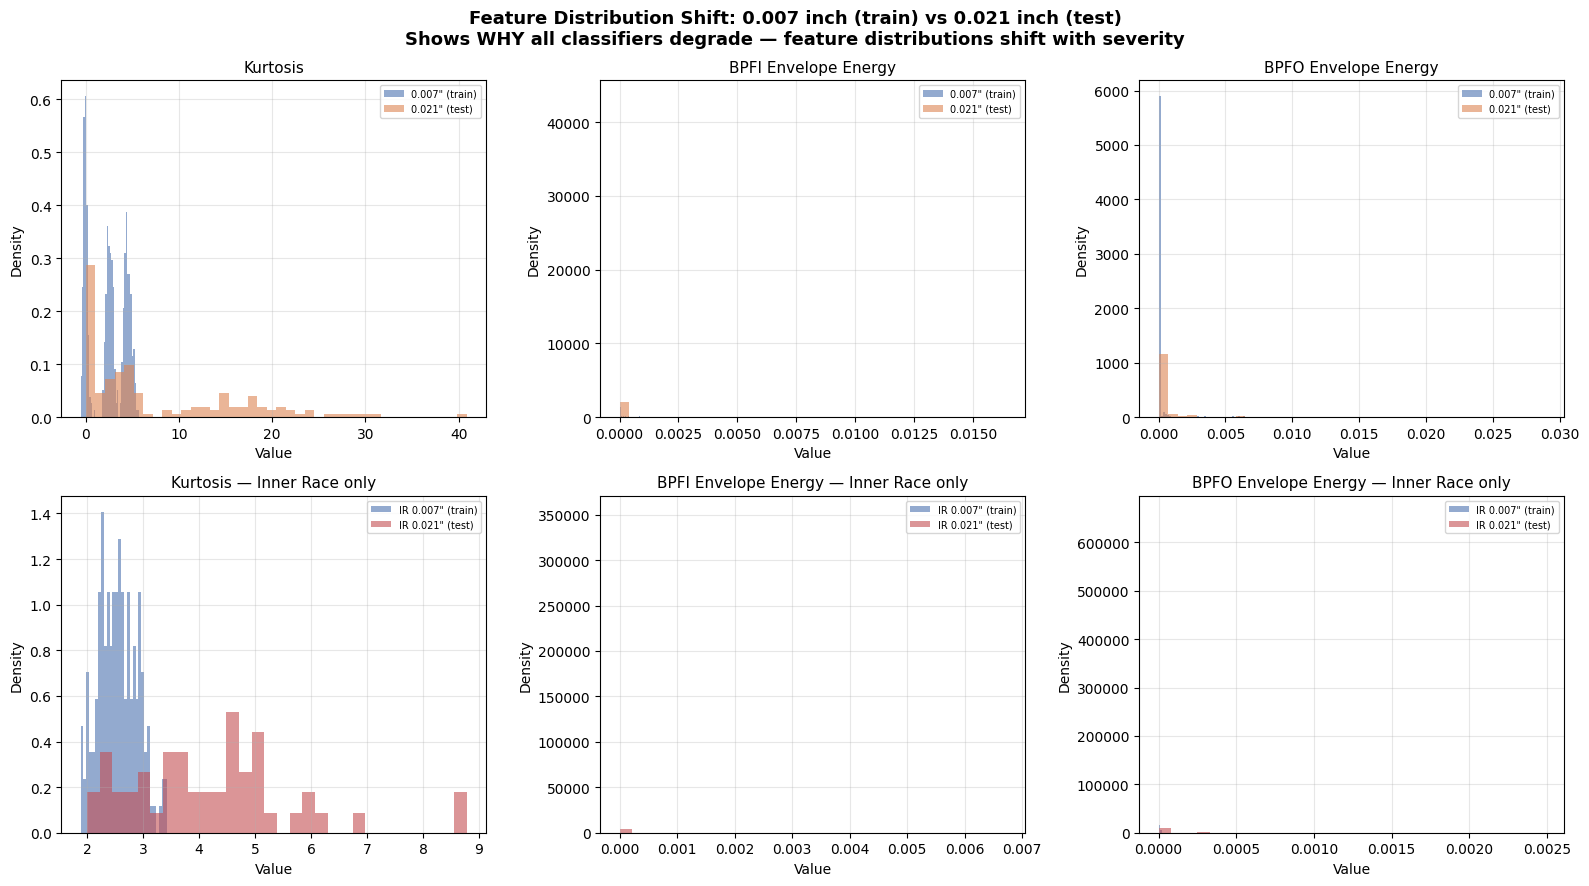

Saved feature_shift_analysis_v5.png


In [27]:
if has_B:
    # Per-class feature shift for the most discriminative features
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(
        f'Feature Distribution Shift: 0.007 inch (train) vs {active_severity} inch (test)\n'
        'Shows WHY all classifiers degrade — feature distributions shift with severity',
        fontsize=13, fontweight='bold'
    )

    plot_features = ['kurtosis', 'BPFI_band', 'BPFO_band']
    plot_titles   = ['Kurtosis', 'BPFI Envelope Energy', 'BPFO Envelope Energy']
    fault_classes = ['Inner Race', 'Outer Race', 'Ball']

    # Row 1: all faults combined
    for ax, feat, title in zip(axes[0], plot_features, plot_titles):
        train_vals = df_train_A[df_train_A['label'] != 0][feat].values
        test_vals  = df_test_B[df_test_B['label']  != 0][feat].values
        ax.hist(train_vals, bins=40, alpha=0.6, color='#4C72B0',
                label='0.007\" (train)', density=True)
        ax.hist(test_vals,  bins=40, alpha=0.6, color='#DD8452',
                label=f'{active_severity}\" (test)', density=True)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    # Row 2: Inner Race only — the class all classifiers fail on
    for ax, feat, title in zip(axes[1], plot_features, plot_titles):
        train_ir = df_train_A[df_train_A['label_name'] == 'Inner Race'][feat].values
        test_ir  = df_test_B[df_test_B['label_name']   == 'Inner Race'][feat].values
        ax.hist(train_ir, bins=30, alpha=0.6, color='#4C72B0',
                label='IR 0.007\" (train)', density=True)
        ax.hist(test_ir,  bins=30, alpha=0.6, color='#C44E52',
                label=f'IR {active_severity}\" (test)', density=True)
        ax.set_title(f'{title} — Inner Race only', fontsize=11)
        ax.set_xlabel('Value')
        ax.set_ylabel('Density')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('feature_shift_analysis_v5.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved feature_shift_analysis_v5.png')

## Side-by-Side Confusion Matrices

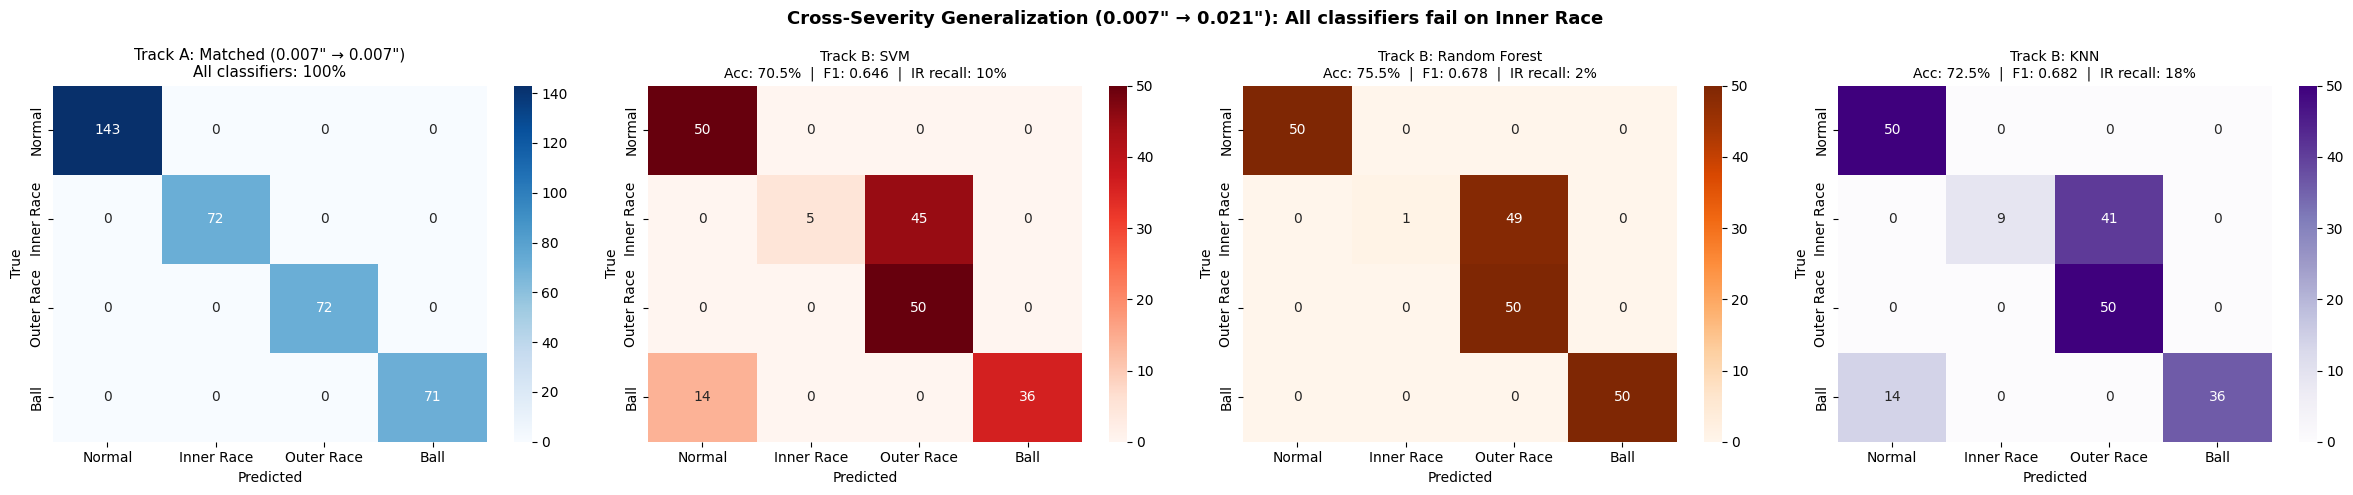

Saved baseline_comparison_v5.png


In [28]:
if has_B:
    n_clf = len(results)
    fig, axes = plt.subplots(1, n_clf + 1, figsize=(6 * (n_clf + 1), 5))

    # Track A (any classifier — all 100%)
    sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=axes[0])
    axes[0].set_title(
        f'Track A: Matched (0.007" → 0.007")\nAll classifiers: 100%',
        fontsize=11
    )
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

    # Track B — one heatmap per classifier
    cmaps = ['Reds', 'Oranges', 'Purples']
    for i, (name, res) in enumerate(results.items()):
        ax = axes[i + 1]
        sns.heatmap(res['cm'], annot=True, fmt='d', cmap=cmaps[i % len(cmaps)],
                    xticklabels=target_names, yticklabels=target_names, ax=ax)
        ax.set_title(
            f'Track B: {name}\n'
            f'Acc: {res["acc"]*100:.1f}%  |  F1: {res["f1"]:.3f}  |  '
            f'IR recall: {res["cm"][1,1]/max(res["cm"][1].sum(),1)*100:.0f}%',
            fontsize=10
        )
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')

    plt.suptitle(
        f'Cross-Severity Generalization (0.007" → {active_severity}"): '
        f'All classifiers fail on Inner Race',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('baseline_comparison_v5.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved baseline_comparison_v5.png')
else:
    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names, ax=ax)
    ax.set_title(f'Track A: Matched (0.007" → 0.007")\nAccuracy: {acc_A*100:.1f}%')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig('baseline_comparison_v5.png', dpi=150, bbox_inches='tight')
    plt.show()

## Textualize Features for Notebook 3

In [29]:
def textualize_features(row):
    """Human-readable feature summary for LLM prompt."""
    text = (
        f"Bearing vibration analysis (CWRU drive-end, {FS//1000}kHz, {RPM} RPM):\n"
        f"- RMS amplitude: {row['rms']:.4f} g\n"
        f"- Peak amplitude: {row['peak']:.4f} g\n"
        f"- Crest factor: {row['crest_factor']:.2f}\n"
        f"- Kurtosis: {row['kurtosis']:.3f} (>3 = impulsive)\n"
        f"- Skewness: {row['skewness']:.3f}\n"
        f"- Shape factor: {row['shape_factor']:.3f}\n"
        f"- Impulse factor: {row['impulse_factor']:.3f}\n"
        f"- Dominant frequency: {row['dom_freq_hz']:.1f} Hz "
        f"(mag: {row['dom_magnitude']:.5f})\n"
        f"- Spectral centroid: {row['spec_centroid']:.1f} Hz | "
        f"Spread: {row['spec_spread']:.1f} Hz\n"
        f"Envelope spectrum band energies (squared envelope, Smith & Randall method):\n"
        f"  BPFI  ({BPFI:.1f}±{BW}Hz): {row['BPFI_band']:.8f}\n"
        f"  BPFO  ({BPFO:.1f}±{BW}Hz): {row['BPFO_band']:.8f}\n"
        f"  BSF   ({BSF:.1f}±{BW_bsf}Hz):  {row['BSF_band']:.8f}\n"
        f"  BPFI lower sideband (BPFI-fr): {row['BPFI_sb_lo']:.8f}\n"
        f"  BPFI upper sideband (BPFI+fr): {row['BPFI_sb_hi']:.8f}\n"
        f"  BSF-FTF sideband:              {row['BSF_ftf_sb_lo']:.8f}\n"
        f"  BSF+FTF sideband:              {row['BSF_ftf_sb_hi']:.8f}\n"
        f"  FTF cage ({FTF:.1f}±4Hz):     {row['FTF_band']:.8f}"
    )
    return text

# Textualize Track A test set (SVM — all classifiers agree at 100%)
df_test_A = df_test_A.copy()
df_test_A['svm_pred']      = y_pred_A
df_test_A['svm_pred_name'] = [LABEL_MAP[p] for p in y_pred_A]
df_test_A['svm_correct']   = (y_pred_A == y_test_A)
for cid in range(4):
    col = f'svm_prob_{LABEL_MAP[cid].replace(" ","_")}'
    df_test_A[col] = y_proba_A[:, cid]
df_test_A['text'] = df_test_A.apply(textualize_features, axis=1)
print('Track A textualized.')

# Textualize Track B — store predictions from ALL classifiers
if has_B:
    df_test_B = df_test_B.copy()
    # Best classifier predictions (for TTC input)
    df_test_B['best_clf_name']      = best_name
    df_test_B['svm_pred']           = results['SVM']['pred']
    df_test_B['svm_pred_name']      = [LABEL_MAP[p] for p in results['SVM']['pred']]
    df_test_B['svm_correct']        = (results['SVM']['pred'] == y_test_B)
    for cid in range(4):
        col = f'svm_prob_{LABEL_MAP[cid].replace(" ","_")}'
        df_test_B[col] = results['SVM']['proba'][:, cid]

    # Also store best classifier predictions
    df_test_B['best_pred']          = best_pred
    df_test_B['best_pred_name']     = [LABEL_MAP[p] for p in best_pred]
    df_test_B['best_correct']       = (best_pred == y_test_B)
    for cid in range(4):
        col = f'best_prob_{LABEL_MAP[cid].replace(" ","_")}'
        df_test_B[col] = best_proba[:, cid]

    df_test_B['text'] = df_test_B.apply(textualize_features, axis=1)
    print(f'Track B textualized (SVM + {best_name} predictions stored).')

Track A textualized.
Track B textualized (SVM + Random Forest predictions stored).


## Envelope Band Energy Diagnostics

Print per-class mean band energies and ratios from the new non-overlapping bands.
These numbers feed the decision thresholds in Notebook 3's system prompt.
**Important:** re-calibrate thresholds after every feature pipeline change.

In [30]:
if has_B:
    print(f'=== ENVELOPE BAND ENERGIES BY FAULT CLASS ({active_severity} inch) ===\n')
    for fault in ['Normal', 'Inner Race', 'Outer Race', 'Ball']:
        s = df_test_B[df_test_B['label_name'] == fault]
        if len(s) == 0:
            continue
        print(f'--- {fault} (n={len(s)}) ---')
        for col in ['BPFI_band', 'BPFO_band', 'BSF_band',
                     'BPFI_sb_lo', 'BPFI_sb_hi',
                     'BSF_ftf_sb_lo', 'BSF_ftf_sb_hi', 'FTF_band']:
            if col in s.columns:
                print(f'  {col:20s}: {s[col].mean():.8f}  (std={s[col].std():.8f})')
        bpfi_m = s['BPFI_band'].mean()
        bpfo_m = s['BPFO_band'].mean()
        bsf_m  = s['BSF_band'].mean()
        print(f'  BPFI/BPFO ratio    : {bpfi_m/(bpfo_m+1e-15):.2f}x')
        print(f'  BPFI/BSF  ratio    : {bpfi_m/(bsf_m+1e-15):.2f}x')
        print(f'  BPFO/BSF  ratio    : {bpfo_m/(bsf_m+1e-15):.2f}x')
        sb_sum = s['BPFI_sb_lo'].mean() + s['BPFI_sb_hi'].mean()
        print(f'  BPFI sideband/BPFI : {sb_sum/(bpfi_m+1e-15):.2f}x')
        ftf_sum = s['BSF_ftf_sb_lo'].mean() + s['BSF_ftf_sb_hi'].mean()
        print(f'  BSF-FTF sb/BSF     : {ftf_sum/(bsf_m+1e-15):.2f}x')
        print()

    # Highlight the Inner Race problem
    ir_recall_svm = results['SVM']['cm'][1,1] / max(results['SVM']['cm'][1].sum(), 1)
    ir_recall_best = results[best_name]['cm'][1,1] / max(results[best_name]['cm'][1].sum(), 1)
    print(f'>>> Inner Race recall: SVM={ir_recall_svm*100:.0f}%, {best_name}={ir_recall_best*100:.0f}%')
    print(f'>>> All classifiers misclassify IR as OR at {active_severity}" severity')
    print(f'>>> TTC target: recover IR classification using envelope ratio reasoning')
    print(f'>>> Copy the ratios above into Notebook 3 system prompt thresholds.')

=== ENVELOPE BAND ENERGIES BY FAULT CLASS (0.021 inch) ===

--- Normal (n=50) ---
  BPFI_band           : 0.00000000  (std=0.00000000)
  BPFO_band           : 0.00000000  (std=0.00000001)
  BSF_band            : 0.00000000  (std=0.00000000)
  BPFI_sb_lo          : 0.00000000  (std=0.00000000)
  BPFI_sb_hi          : 0.00000000  (std=0.00000000)
  BSF_ftf_sb_lo       : 0.00000000  (std=0.00000001)
  BSF_ftf_sb_hi       : 0.00000000  (std=0.00000001)
  FTF_band            : 0.00000000  (std=0.00000001)
  BPFI/BPFO ratio    : 0.21x
  BPFI/BSF  ratio    : 0.46x
  BPFO/BSF  ratio    : 2.20x
  BPFI sideband/BPFI : 4.39x
  BSF-FTF sb/BSF     : 4.09x

--- Inner Race (n=50) ---
  BPFI_band           : 0.00041092  (std=0.00124344)
  BPFO_band           : 0.00017634  (std=0.00048624)
  BSF_band            : 0.00014655  (std=0.00049862)
  BPFI_sb_lo          : 0.00020732  (std=0.00069933)
  BPFI_sb_hi          : 0.00033726  (std=0.00107122)
  BSF_ftf_sb_lo       : 0.00024204  (std=0.00068407)
  BS

## Save baseline_results.pkl

In [31]:
baseline_results = {
    'track_A': {
        'df_test':          df_test_A,
        'svm_pipeline':     svm_A,
        'y_pred':           y_pred_A,
        'y_test':           y_test_A,
        'y_proba':          y_proba_A,
        'accuracy':         acc_A,
        'f1_macro':         f1_A,
        'confusion_matrix': cm_A,
        'n_misclassified':  int((y_pred_A != y_test_A).sum()),
        'description':      '0HP, 0.007 inch matched condition',
    },
    'track_B': {
        'df_test':          df_test_B          if has_B else None,
        'y_pred':           results['SVM']['pred']   if has_B else None,
        'y_test':           y_test_B           if has_B else None,
        'y_proba':          results['SVM']['proba']  if has_B else None,
        'accuracy':         results['SVM']['acc']    if has_B else None,
        'f1_macro':         results['SVM']['f1']     if has_B else None,
        'confusion_matrix': results['SVM']['cm']     if has_B else None,
        'n_misclassified':  results['SVM']['n_wrong'] if has_B else 0,
        'description':      f'0.007 inch train → {active_severity} inch test (cross-severity)'
                            if has_B else 'NOT AVAILABLE',
        'active_severity':  active_severity    if has_B else None,
        'available':        has_B,
    },
    # Multi-classifier comparison (new in v5)
    'multi_classifier': {
        name: {
            'accuracy':         res['acc'],
            'f1_macro':         res['f1'],
            'confusion_matrix': res['cm'],
            'n_misclassified':  res['n_wrong'],
        }
        for name, res in results.items()
    } if has_B else {},
    'best_classifier':  best_name if has_B else 'SVM',
    'label_map':        LABEL_MAP,
    'feature_cols':     FEATURE_COLS,
    'bearing_params': {
        'RPM': RPM, 'FS': FS, 'FR': FR,
        'BPFO': BPFO, 'BPFI': BPFI, 'BSF': BSF, 'FTF': FTF,
        'BW': BW, 'BW_bsf': BW_bsf,
    },
    'feature_version':  'v5_envelope_spectrum',
}

with open('baseline_results.pkl', 'wb') as f:
    pickle.dump(baseline_results, f)

print('Saved baseline_results.pkl')
print()
print('=== SUMMARY ===')
print(f'Feature pipeline : Envelope spectrum (Smith & Randall)')
print(f'Track A (matched):       {acc_A*100:.2f}% — all classifiers 100%')
if has_B:
    print(f'\nTrack B cross-severity ({active_severity} inch):')
    for name in results:
        r = results[name]
        ir_recall = r['cm'][1,1] / max(r['cm'][1].sum(), 1)
        print(f'  {name:15s}: {r["acc"]*100:.1f}% acc, '
              f'{r["n_wrong"]} misclassified, '
              f'IR recall={ir_recall*100:.0f}%')
    print(f'\n  Best on Track B: {best_name} ({results[best_name]["acc"]*100:.1f}%)')
    print(f'  TTC input uses: SVM predictions (for comparison with {best_name})')
    print(f'  Key finding: all classifiers fail on Inner Race '
          f'(recall ≤{max(results[n]["cm"][1,1]/max(results[n]["cm"][1].sum(),1) for n in results)*100:.0f}%)')
else:
    print('Track B: NOT available.')
print('\nReady for Notebook 3.')

Saved baseline_results.pkl

=== SUMMARY ===
Feature pipeline : Envelope spectrum (Smith & Randall)
Track A (matched):       100.00% — all classifiers 100%

Track B cross-severity (0.021 inch):
  SVM            : 70.5% acc, 59 misclassified, IR recall=10%
  Random Forest  : 75.5% acc, 49 misclassified, IR recall=2%
  KNN            : 72.5% acc, 55 misclassified, IR recall=18%

  Best on Track B: Random Forest (75.5%)
  TTC input uses: SVM predictions (for comparison with Random Forest)
  Key finding: all classifiers fail on Inner Race (recall ≤18%)

Ready for Notebook 3.
